In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import fill
import numpy as np
import pandas as pd
import scanpy.external as sce
import scanpy as sc
import anndata as an
from scipy.spatial.distance import cdist
import scvelo as scv
import gget
import rapids_singlecell as rsc
# import cellrank as cr

import warnings
warnings.filterwarnings("ignore")

sc.settings.verbosity = 3 

print(scv.__version__)

0.3.3


# Load expression

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['log_norm'].copy()
adata

CPU times: user 927 ms, sys: 3.36 s, total: 4.28 s
Wall time: 10 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

In [3]:
print(f"{len(adata.obs_names)=}")
print(f"{adata.obs_names.nunique()=}")

len(adata.obs_names)=15867
adata.obs_names.nunique()=15867


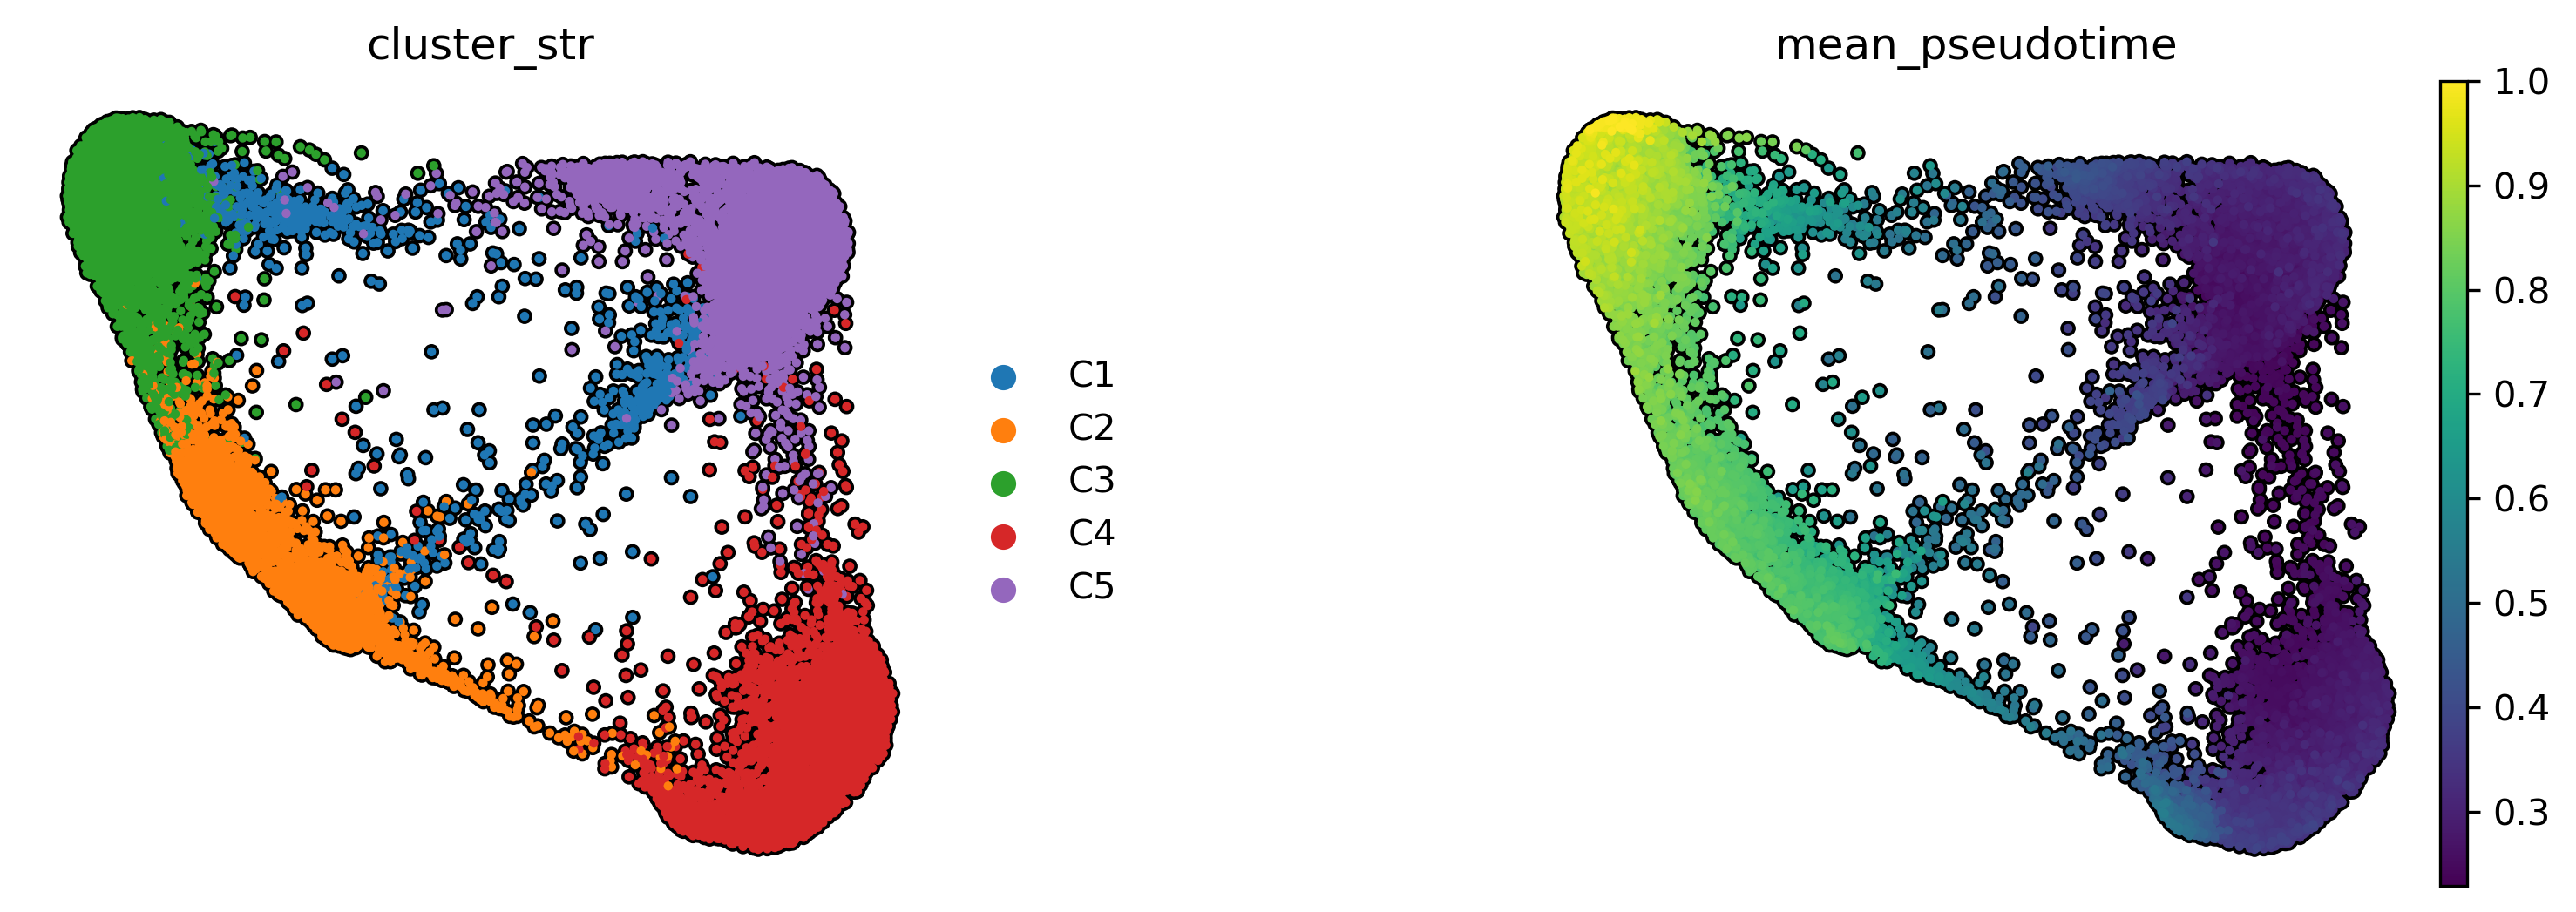

In [4]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['cluster_str', 'mean_pseudotime'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [5]:
# break

# Load Velocity

In [6]:
%%time

fpaths = {
    "hsc" : "/scratch/indikar_root/indikar1/shared_data/hsc_velocyto/merged_NKUVW.loom",
    "fib" : "/scratch/indikar_root/indikar1/shared_data/fib_velocyto/merged_PW6SH.loom",
}

ldatas = []
for key, fpath in fpaths.items():
    print(f"Working {key}...")

    ldata = sc.read_loom(fpath)
    ldata.var_names_make_unique()

    # set the cell-ids back to barcodes
    ldata.obs['velocyto_cell_id'] = ldata.obs_names.copy()
    ldata.obs['cell_id'] = ldata.obs['velocyto_cell_id'].apply(lambda x: x.split(":")[1][:-1] + "-1")
    ldata.obs_names = ldata.obs['cell_id'].values

    # Print initial cell counts
    print(f"\tInitial cell count in ldata: {ldata.shape[0]}")
    print(f"\tInitial cell count in adata: {adata.shape[0]}")
    
    # IDs not retained in ldata
    removed_from_ldata = ldata.obs.index[~ldata.obs.index.isin(adata.obs_names)].tolist()
    
    # IDs not retained in adata
    removed_from_adata = adata.obs.index[~adata.obs.index.isin(ldata.obs_names)].tolist()
    
    # Filter ldata to keep only cells present in adata
    initial_ldata_count = ldata.shape[0]
    ldata = ldata[ldata.obs.index.isin(adata.obs_names), :].copy()
    print(f"\tFiltered ldata: {ldata.shape[0]} cells kept, {initial_ldata_count - ldata.shape[0]} cells removed")

    ldatas.append(ldata)

    
ldata = an.concat(ldatas)   
ldata

Working hsc...
	Initial cell count in ldata: 11933
	Initial cell count in adata: 15867
	Filtered ldata: 8326 cells kept, 3607 cells removed
Working fib...
	Initial cell count in ldata: 8963
	Initial cell count in adata: 15867
	Filtered ldata: 7541 cells kept, 1422 cells removed
CPU times: user 1min 21s, sys: 28.7 s, total: 1min 50s
Wall time: 1min 51s


AnnData object with n_obs × n_vars = 15867 × 38606
    obs: 'velocyto_cell_id', 'cell_id'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

# Merge and Filter

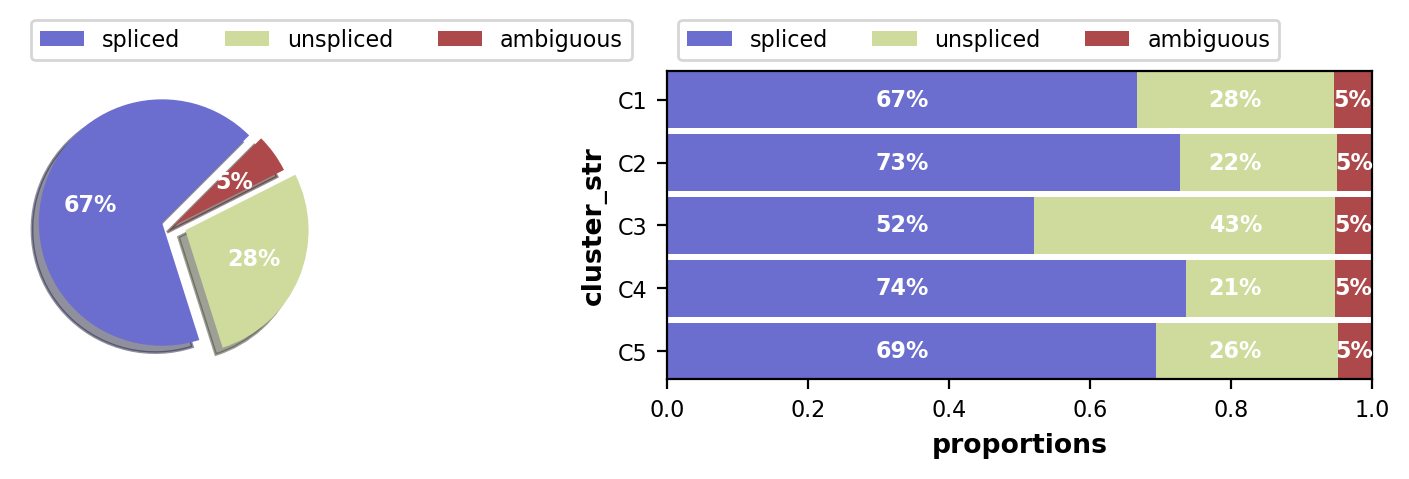

AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total

In [7]:
adata = scv.utils.merge(adata, ldata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 7, 5

scv.pl.proportions(adata, groupby='cluster_str', dpi=200)

adata

In [8]:
# break

# RNA Velocity

In [12]:
%%time
rsc.pp.neighbors(adata, n_neighbors=55, use_rep='X_pca_harmony')
scv.pp.moments(adata, use_rep='X_pca_harmony')

scv.tl.recover_dynamics(adata, n_jobs=8) 

[2025-05-13 11:00:10.299] [CUML] [debug] n_neighbors=55
[2025-05-13 11:00:10.299] [CUML] [debug] Calling knn graph run
[2025-05-13 11:00:10.299] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-13 11:00:10.304] [CUML] [debug] Done. Calling remove zeros
ERROR! Session/line number was not unique in database. History logging moved to new session 6321
computing moments based on connectivities
    finished (0:00:37) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 8/40 cores)


  0%|          | 0/697 [00:00<?, ?gene/s]

    finished (0:08:04) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
CPU times: user 1min 33s, sys: 44.4 s, total: 2min 17s
Wall time: 8min 42s


In [ ]:
break

computing velocities
    finished (0:00:33) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
        Consider computing the graph in an unbiased manner 
        on full expression space by not specifying basis.

computing velocity graph (using 8/40 cores)


  0%|          | 0/15867 [00:00<?, ?cells/s]

    finished (0:00:24) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:06) --> added
    'velocity_draw_graph_fa', embedded velocity vectors (adata.obsm)


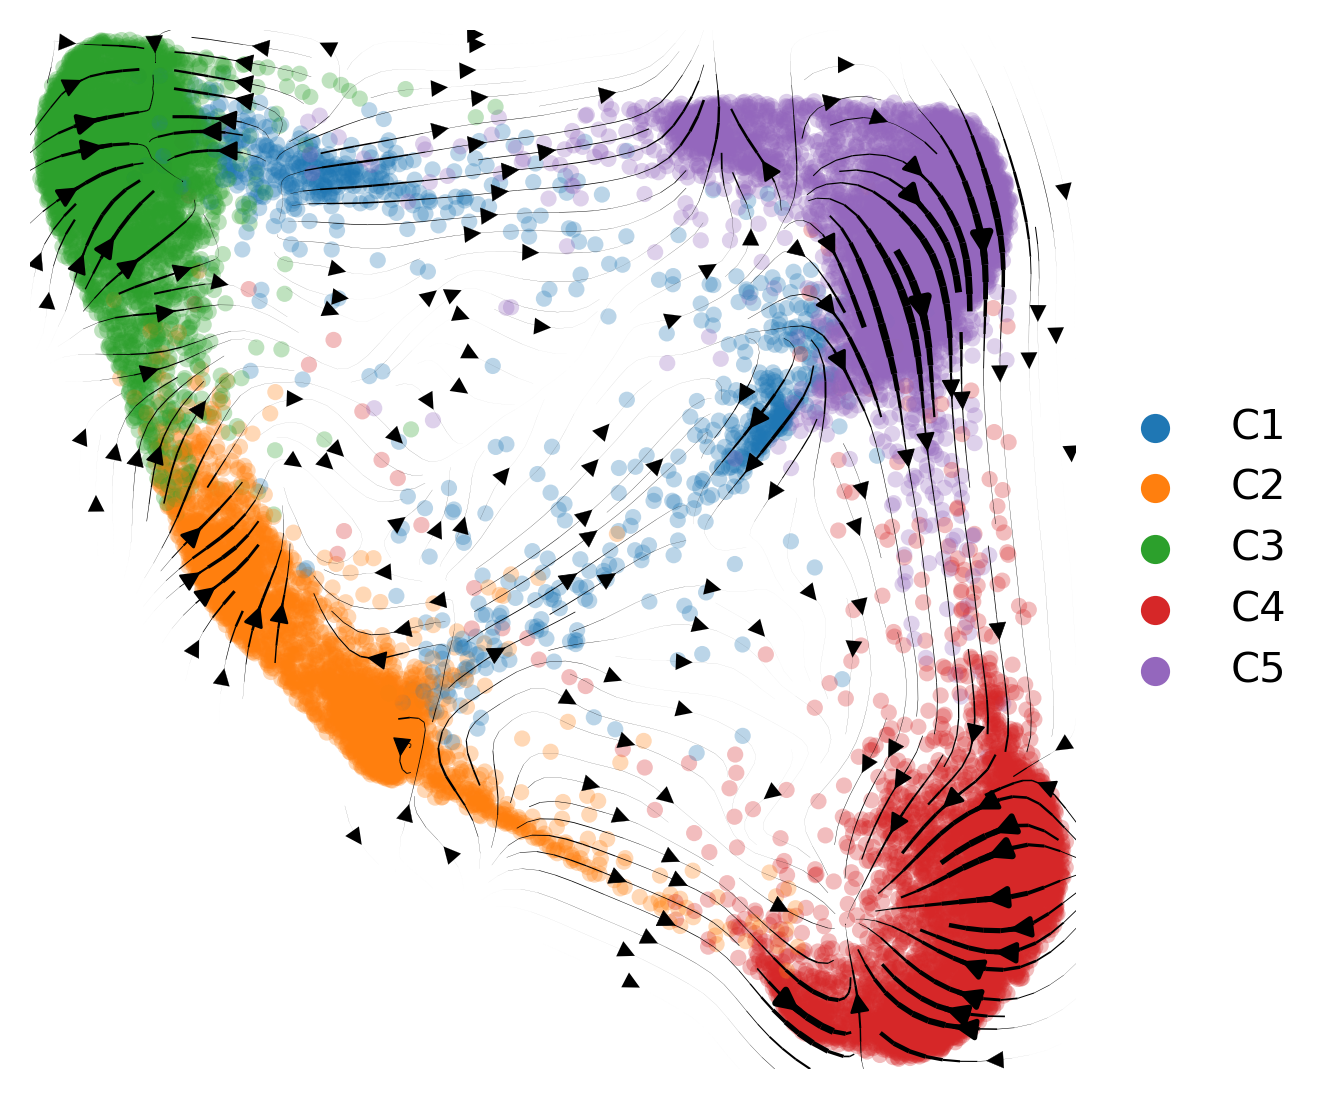

CPU times: user 57 s, sys: 32.4 s, total: 1min 29s
Wall time: 1min 32s


In [15]:
%%time
scv.tl.velocity(adata, mode='dynamical')

scv.tl.velocity_graph(
    adata, 
    n_jobs=8,
    basis='X_pca_harmony',
    n_neighbors=155,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4.5, 4.5

scv.pl.velocity_embedding_stream(
    adata, 
    basis='X_draw_graph_fa',
    color='cluster_str',
    smooth=True,
    title="",
    legend_loc='right_margin',
)

# Latent Time

In [ ]:
%%time
def find_closest_cell(adata, obs_key='barcoded_phase', value='G1', obsm_key='X_pca'):
    """
    Find the cell closest to a median vector in PCA space.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group
        value (str): The value for aggregation 
        obsm_key (str): Key in adata.obsm for PCA or other embedding.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest G1 cell in adata.obs_names
    """
    mask = adata.obs[obs_key] == value
    emb = adata.obsm[obsm_key][mask]

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index


root_id, root_key = find_closest_cell(
    adata,
    obs_key='cluster_str',
    value='C5',
)

print(f"{root_id=} {root_key=}")

end_id, end_key = find_closest_cell(
    adata,
    obs_key='cluster_str',
    value='C3',
)

print(f"{end_id=} {end_key=}")

scv.tl.latent_time(
    adata, 
    root_key=root_key,
    end_key=end_key,
)

scv.pl.scatter(
    adata, 
    basis='X_draw_graph_fa', 
    color='latent_time', 
    color_map='gnuplot',
)

In [ ]:
break

In [ ]:
scv.tl.rank_velocity_genes(adata, groupby='cluster_str', min_corr=.3)

df = pd.DataFrame(adata.uns['rank_velocity_genes']['names'])
print(df.head(25).to_string())

In [ ]:
# ?scv.pl.scatter

In [ ]:
scv.pl.scatter(
    adata, 
    basis=['AHNAK2' ,'CLU', 'ENO1'],
    color='cluster_str', 
    smooth=True,
    frameon=False,
)

In [ ]:
break

# Recover Dynamics

In [ ]:
%%time
scv.tl.recover_dynamics(adata, n_jobs=8) 

In [ ]:
%%time
def find_closest_cell(adata, obs_key='barcoded_phase', value='G1', obsm_key='X_pca'):
    """
    Find the cell closest to a median vector in PCA space.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group
        value (str): The value for aggregation 
        obsm_key (str): Key in adata.obsm for PCA or other embedding.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest G1 cell in adata.obs_names
    """
    mask = adata.obs[obs_key] == value
    emb = adata.obsm[obsm_key][mask]

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index



root_key, root_idx = find_closest_cell(
    adata,
    obs_key='cluster_str',
    value='C5',
)

print(f"{root_key=} {root_idx=}")

scv.tl.latent_time(adata, root_key=root_idx)

In [ ]:
%%time
root_key, root_idx = find_closest_cell(
    adata,
    obs_key='cluster_str',
    value='C5',
)

print(f"{root_key=} {root_idx=}")

scv.tl.latent_time(adata, root_key=root_idx)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata, 
    color='latent_time',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    cmap='gnuplot',
)

In [ ]:
n_genes = 35
count_thr = 500
top_genes = adata.var.sort_values(by='fit_likelihood', ascending=False)
top_genes = top_genes[top_genes['n_cells'] > count_thr]
top_genes.head()

top_genes = top_genes.index[:n_genes]

plt.rcParams['figure.dpi'] = 200

scv.pl.heatmap(
    adata, 
    var_names=top_genes, 
    sortby='velocity_pseudotime', 
    col_color='cluster_str', 
    figsize=(8, 5),
    yticklabels=True,
    n_convolve=30,
    palette='Reds',
)

In [ ]:
break

In [ ]:
# break